In [13]:
import pandas as pd

df = pd.read_csv("amazon_reviews.csv")
df.head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,reviewText,overall,productCategory
0,"Excellent product, works perfectly",5,Electronics
1,Very good quality and fast delivery,4,Electronics
2,"Average performance, not bad",3,Electronics
3,Stopped working after few days,1,Electronics
4,Not worth the money,2,Electronics


In [14]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['overall'].apply(rating_to_sentiment)

df.head()

,reviewText,overall,productCategory,sentiment
0,"Excellent product, works perfectly",5,Electronics,Positive
1,Very good quality and fast delivery,4,Electronics,Positive
2,"Average performance, not bad",3,Electronics,Neutral
3,Stopped working after few days,1,Electronics,Negative
4,Not worth the money,2,Electronics,Negative


In [15]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['clean_text'] = df['reviewText'].apply(clean_text)

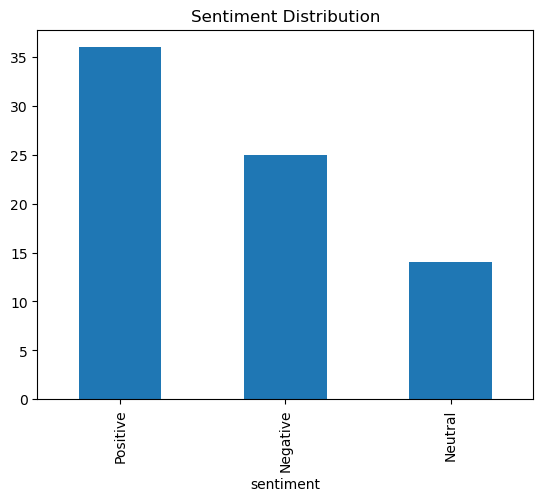

In [16]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

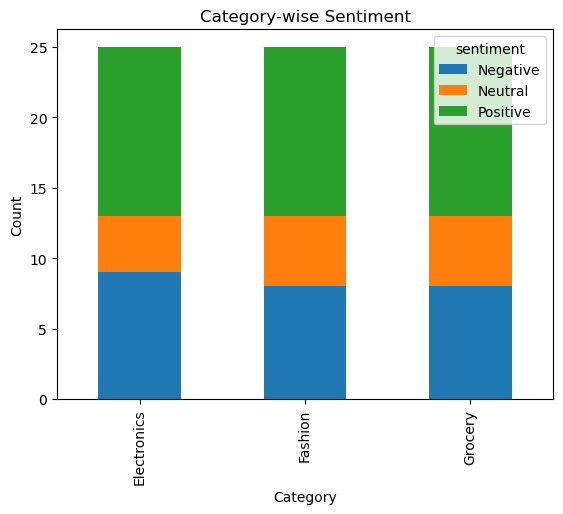

In [17]:
category_sentiment = pd.crosstab(df['productCategory'], df['sentiment'])
category_sentiment.plot(kind='bar', stacked=True)

plt.title("Category-wise Sentiment")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [18]:
!pip install wordcloud

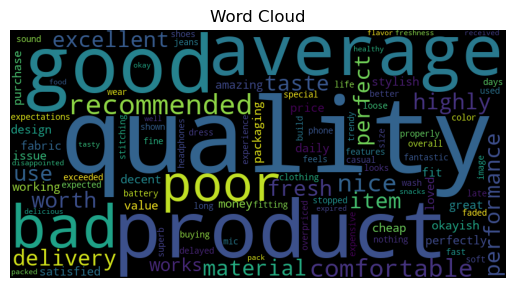

In [19]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

INSIGHTS

Majority of reviews are positive, indicating customer satisfaction
Electronics category shows mixed sentiment due to performance issues
Fashion products highlight concerns about size and material
Grocery items show strong positivity due to freshness and taste